===  FSS ===
pc = 0.9952887062883033 ± 0.019193491905024593
nu = 2.68785218866514 ± 0.18223671979039485
zeta = 0.41893659737961064 ± 0.7008862994823822
スケーリング品質 S = 776.823200578073


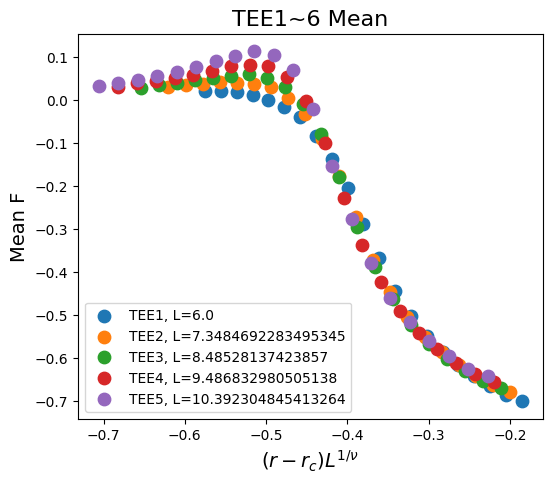

/home/kataoka/anaconda3/envs/pyfssa_env/lib/python3.8/site-packages/fssa/fssa.py:227: RuntimeWarning: divide by zero encountered in double_scalars
  m = 1. / delta * (k * kxy - kx * ky)
/home/kataoka/anaconda3/envs/pyfssa_env/lib/python3.8/site-packages/fssa/fssa.py:228: RuntimeWarning: divide by zero encountered in double_scalars
  b = 1. / delta * (kxx * ky - kx * kxy)
/home/kataoka/anaconda3/envs/pyfssa_env/lib/python3.8/site-packages/fssa/fssa.py:229: RuntimeWarning: divide by zero encountered in double_scalars
  b_var = kxx / delta
/home/kataoka/anaconda3/envs/pyfssa_env/lib/python3.8/site-packages/fssa/fssa.py:230: RuntimeWarning: divide by zero encountered in double_scalars
  m_var = k / delta
/home/kataoka/anaconda3/envs/pyfssa_env/lib/python3.8/site-packages/fssa/fssa.py:231: RuntimeWarning: divide by zero encountered in double_scalars
  bm_covar = - kx / delta
/home/kataoka/anaconda3/envs/pyfssa_env/lib/python3.8/site-packages/fssa/fssa.py:234: RuntimeWarning: invalid value e

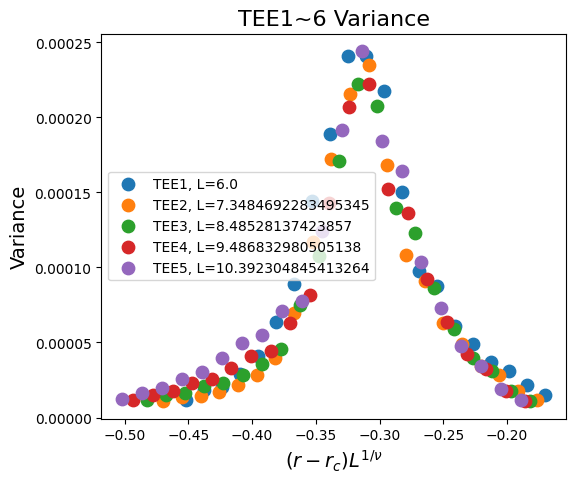

=== 分散 FSS ===
pc = 1.0207136472344467 ± 93265.17972213421
nu = 5.230006818088688 ± 2195388.6003507413
zeta = 10.061368168626 ± 3568191.31475163
スケーリング品質 S = 0.011638377509632508


In [9]:
import numpy as np
import fssa
import matplotlib.pyplot as plt
import matplotlib.cm as cm

gamma = 0.5
#markers = ['x', 'o', '^', 's']
#colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3']  

# TEEと対応するL
#L_list = [12, 18, 24, 30]
L_list     = [np.sqrt(36), np.sqrt(54), np.sqrt(72), np.sqrt(90), np.sqrt(108)]
TEE_keys = ['TEE2', 'TEE3', 'TEE4', 'TEE5', 'TEE6']

#L_list = [4, 6, 7, 8, 9, 10]
#TEE_keys = ['TEE1', 'TEE2', 'TEE3', 'TEE4',  'TEE5', 'TEE6']

# データ読み込み
#data = np.load("Lx_12_Nd_100_NT_4320_px_0.0_MPI_hexagonal6.npz")
data = np.load("Lx_24_Nd_500_NT_17280_px_0.0_MPI_hexagonal6.npz")
p_use = data['pg']

cmap = cm.get_cmap('gnuplot', 4)

# ----------------------
# 平均値 FSS
# ----------------------
a_mean = np.array([data[f'{k}_ave'] for k in TEE_keys], dtype=float)
da_mean = np.array([data[f'{k}_err'] for k in TEE_keys], dtype=float) * gamma

ret_mean = fssa.autoscale(L_list, p_use, a_mean, da_mean, rho_c0=0.85, nu0=2, zeta0=2)
xs_mean, ys_mean, dys_mean = fssa.scaledata(L_list, p_use, a_mean, da_mean,
                                            ret_mean.rho, ret_mean.nu, ret_mean.zeta)

print("===  FSS ===")
print("pc =", ret_mean.rho, "±", ret_mean.drho)
print("nu =", ret_mean.nu, "±", ret_mean.dnu)
print("zeta =", ret_mean.zeta, "±", ret_mean.dzeta)
print("スケーリング品質 S =", fssa.quality(xs_mean, ys_mean, dys_mean))

# ----------------------
# 平均のプロット
# ----------------------
fig, ax = plt.subplots(figsize=(6,5))
for i, L in enumerate(L_list):
    ax.scatter(xs_mean.T[:,i], ys_mean.T[:,i],
               label=f'TEE{i+1}, L={L}', s=80)
ax.set_xlabel(r'$(r-r_c)L^{1/\nu}$', fontsize=14)
ax.set_ylabel('Mean F', fontsize=14)
ax.legend()
plt.title('TEE1~6 Mean', fontsize=16)

# PNG保存
plt.savefig("TEE_mean1-6.png", dpi=300, bbox_inches='tight')

# 図を表示（必要な場合）
plt.show()
plt.close(fig)  # メモリ解放
# ----------------------
# 分散 FSS
# ----------------------
a_var = np.array([data[f'{k}_var'] for k in TEE_keys], dtype=float)
da_var = np.array([data[f'{k}_err'] for k in TEE_keys], dtype=float) * 2.0  # 誤差の扱いは場合に応じて

ret_var = fssa.autoscale(L_list, p_use, a_var, da_var, rho_c0=0.85, nu0=1.8, zeta0=2)
xs_var, ys_var, dys_var = fssa.scaledata(L_list, p_use, a_var, da_var,
                                         ret_var.rho, ret_var.nu, ret_var.zeta)

# ----------------------
# 分散のプロット
# ----------------------
fig, ax = plt.subplots(figsize=(6,5))
for i, L in enumerate(L_list):
    ax.scatter(xs_var.T[:,i], ys_var.T[:,i],
               label=f'TEE{i+1}, L={L}', s=80)
ax.set_xlabel(r'$(r-r_c)L^{1/\nu}$', fontsize=14)
ax.set_ylabel('Variance', fontsize=14)
ax.legend()
plt.title('TEE1~6 Variance', fontsize=16)

# PNG保存
plt.savefig("TEE_variance1-6.png", dpi=300, bbox_inches='tight')

# 図を表示
plt.show()
plt.close(fig)

print("=== 分散 FSS ===")
print("pc =", ret_var.rho, "±", ret_var.drho)
print("nu =", ret_var.nu, "±", ret_var.dnu)
print("zeta =", ret_var.zeta, "±", ret_var.dzeta)
print("スケーリング品質 S =", fssa.quality(xs_var, ys_var, dys_var))




Using p range: [0.720000, 0.900000]  (N=19)


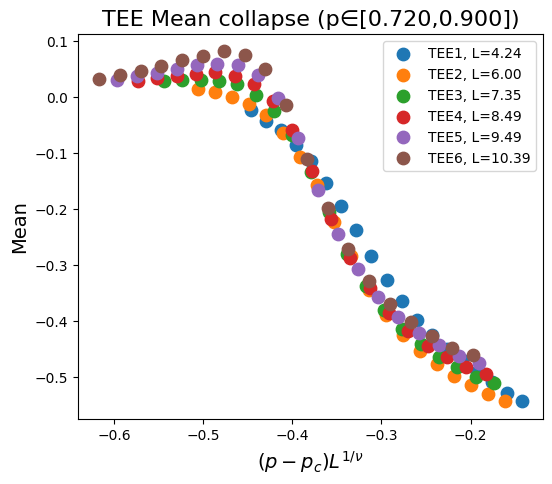

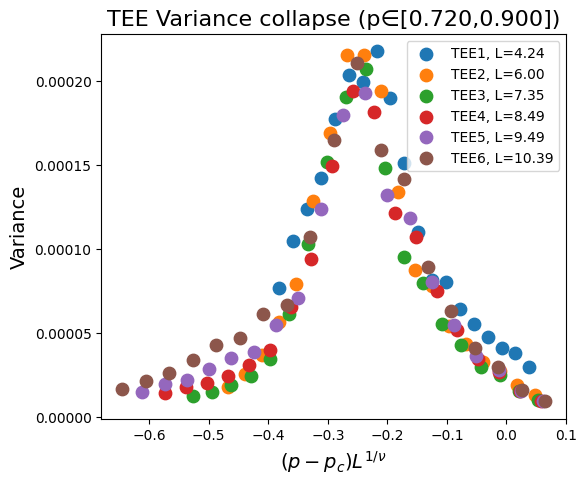

=== 平均 FSS ===
pc = 0.9844040970360879 ± 0.0025535936581012786
nu = 2.7619346253218886 ± 0.03874977302969574
zeta = 0.8227519183989942 ± 0.5025311497851833
S (mean) = 1394.6446256261497

=== 分散 FSS ===
pc = 0.8835461180127383 ± 0.04969894385415566
nu = 1.7062759034647463 ± 0.38260714240090904
zeta = 3.390045265410035 ± 0.6273958239816217
S (var)  = 0.2250437083861608


In [8]:
import numpy as np
import fssa
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ======================
# 設定
# ======================
gamma = 0.5

# L と TEE キー
# L_list は FSSA のスケール長 (L) を入れる。ここでは sqrt(セル数) を使用。
#L_list = [np.sqrt(18), np.sqrt(36), np.sqrt(54), np.sqrt(72), np.sqrt(90), np.sqrt(108)]
#TEE_keys = ['TEE1','TEE2', 'TEE3', 'TEE4', 'TEE5', 'TEE6']

L_list = [np.sqrt(18), np.sqrt(36), np.sqrt(54), np.sqrt(72), np.sqrt(90), np.sqrt(108)]
TEE_keys = ['TEE1', 'TEE2', 'TEE3', 'TEE4', 'TEE5', 'TEE6']

# データファイル
npz_path = "Lx_24_Nd_500_NT_17280_px_0.0_MPI_hexagonal6.npz"

# カラーマップ
cmap = cm.get_cmap('gnuplot', 4)

# ======================
# p の使用範囲の指定（いずれか1つを有効に）
# ======================
# 方式A: 値で指定（例: 0.30 <= p <= 0.90）
use_by_value = True
pmin, pmax = 0.72, 0.9

# 方式B: 連続インデックスで指定（例: 5〜45 まで）
idx_slice = None  # 例: slice(5, 46)

# 方式C: 個別インデックスのリスト（例: 偶数番だけ）
idx_list = None   # 例: [0, 2, 4, 6, 8]

# ======================
# データ読み込み
# ======================
data = np.load(npz_path)
p_all = data['pg']  # 全 p
# a_mean, da_mean, a_var, da_var を先に作り、あとで列方向に同じマスクを適用
a_mean = np.array([data[f'{k}_ave'] for k in TEE_keys], dtype=float)       # shape=(nL, nP)
da_mean = np.array([data[f'{k}_err'] for k in TEE_keys], dtype=float) * gamma
a_var  = np.array([data[f'{k}_var'] for k in TEE_keys], dtype=float)
da_var = np.array([data[f'{k}_err'] for k in TEE_keys], dtype=float) * gamma  # 仮に同じ誤差を使用

# ======================
# マスク作成
# ======================
if use_by_value:
    mask = (p_all >= pmin) & (p_all <= pmax)
elif idx_slice is not None:
    mask = np.zeros_like(p_all, dtype=bool)
    mask[idx_slice] = True
elif idx_list is not None:
    mask = np.zeros_like(p_all, dtype=bool)
    mask[np.array(idx_list, dtype=int)] = True
else:
    mask = np.ones_like(p_all, dtype=bool)  # 全部使う

# 安全チェック
if not np.any(mask):
    raise ValueError("選択マスクが空です。p の範囲やインデックス指定を見直してください。")

# マスク適用（列方向＝p軸に沿って揃える）
p_use = p_all[mask]
a_mean_sel  = a_mean[:,  mask]
da_mean_sel = da_mean[:, mask]
a_var_sel   = a_var[:,   mask]
da_var_sel  = da_var[:,  mask]

print(f"Using p range: [{p_use.min():.6f}, {p_use.max():.6f}]  (N={p_use.size})")

# ======================
# 平均値 FSS
# ======================
ret_mean = fssa.autoscale(L_list, p_use, a_mean_sel, da_mean_sel,
                          rho_c0=0.86, nu0=1.82, zeta0=2.9)
xs_mean, ys_mean, dys_mean = fssa.scaledata(L_list, p_use, a_mean_sel, da_mean_sel,
                                            ret_mean.rho, ret_mean.nu, ret_mean.zeta)

# ----------------------
# 平均のプロット
# ----------------------
fig, ax = plt.subplots(figsize=(6,5))
for i, (L, key) in enumerate(zip(L_list, TEE_keys)):
    ax.scatter(xs_mean.T[:, i], ys_mean.T[:, i],
               label=f'{key}, L={L:.2f}', s=80)
ax.set_xlabel(r'$(p-p_c)L^{1/\nu}$', fontsize=14)
ax.set_ylabel('Mean', fontsize=14)
ax.legend()
plt.title(f"TEE Mean collapse (p∈[{p_use.min():.3f},{p_use.max():.3f}])", fontsize=16)

plt.savefig("TEE_mean.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)

# ======================
# 分散 FSS
# ======================
ret_var = fssa.autoscale(L_list, p_use, a_var_sel, da_var_sel,
                         rho_c0=0.87, nu0=1.73, zeta0=3.3)
xs_var, ys_var, dys_var = fssa.scaledata(L_list, p_use, a_var_sel, da_var_sel,
                                         ret_var.rho, ret_var.nu, ret_var.zeta)

# ----------------------
# 分散のプロット
# ----------------------
fig, ax = plt.subplots(figsize=(6,5))
for i, (L, key) in enumerate(zip(L_list, TEE_keys)):
    ax.scatter(xs_var.T[:, i], ys_var.T[:, i],
               label=f'{key}, L={L:.2f}', s=80)
ax.set_xlabel(r'$(p-p_c)L^{1/\nu}$', fontsize=14)
ax.set_ylabel('Variance', fontsize=14)
ax.legend()
plt.title(f"TEE Variance collapse (p∈[{p_use.min():.3f},{p_use.max():.3f}])", fontsize=16)

plt.savefig("TEE_variance.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)

# ======================
# 結果表示
# ======================
print("=== 平均 FSS ===")
print("pc =", ret_mean.rho, "±", ret_mean.drho)
print("nu =", ret_mean.nu,  "±", ret_mean.dnu)
print("zeta =", ret_mean.zeta, "±", ret_mean.dzeta)
print("S (mean) =", fssa.quality(xs_mean, ys_mean, dys_mean))

print("\n=== 分散 FSS ===")
print("pc =", ret_var.rho, "±", ret_var.drho)
print("nu =", ret_var.nu,  "±", ret_var.dnu)
print("zeta =", ret_var.zeta, "±", ret_var.dzeta)
print("S (var)  =", fssa.quality(xs_var, ys_var, dys_var))


Using p range: [0.720000, 0.900000]  (N=19)


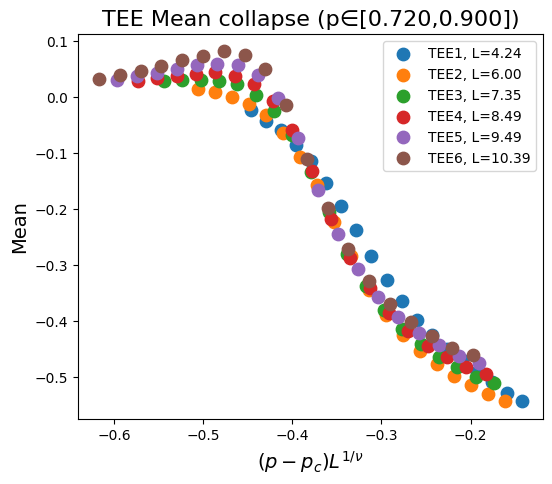

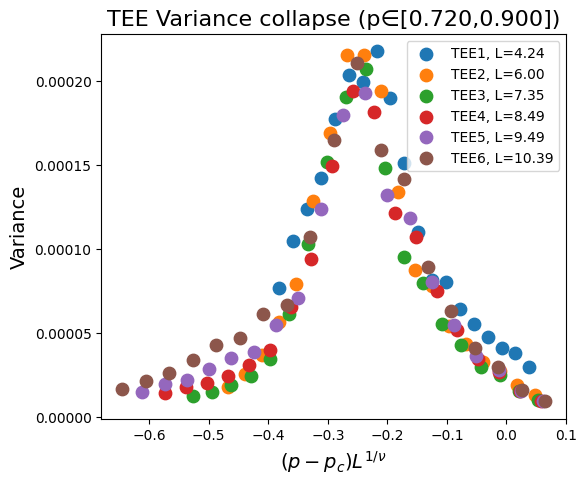

=== 平均 FSS ===
pc = 0.9844040970360879 ± 0.0025535936581012786
nu = 2.7619346253218886 ± 0.03874977302969574
zeta = 0.8227519183989942 ± 0.5025311497851833
S (mean) = 1394.6446256261497

=== 分散 FSS ===
pc = 0.8835461180127383 ± 0.04969894385415566
nu = 1.7062759034647463 ± 0.38260714240090904
zeta = 3.390045265410035 ± 0.6273958239816217
S (var)  = 0.2250437083861608


In [6]:
import numpy as np
import fssa
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ======================
# 設定
# ======================
gamma = 0.5

# L と TEE キー
# L_list は FSSA のスケール長 (L) を入れる。ここでは sqrt(セル数) を使用。
L_list = [np.sqrt(18),np.sqrt(36), np.sqrt(54), np.sqrt(72), np.sqrt(90), np.sqrt(108)]
TEE_keys = ['TEE1','TEE2', 'TEE3', 'TEE4', 'TEE5', 'TEE6']

#L_list = [np.sqrt(36), np.sqrt(54), np.sqrt(72), np.sqrt(90), np.sqrt(108)]
#TEE_keys = ['TEE2', 'TEE3', 'TEE4', 'TEE5', 'TEE6']

#L_list = [np.sqrt(54), np.sqrt(72), np.sqrt(90), np.sqrt(108)]
#TEE_keys = ['TEE3', 'TEE4', 'TEE5', 'TEE6']

# データファイル
npz_path = "Lx_24_Nd_500_NT_17280_px_0.0_MPI_hexagonal6.npz"

# カラーマップ
cmap = cm.get_cmap('gnuplot', 4)

# ======================
# p の使用範囲の指定（いずれか1つを有効に）
# ======================
# 方式A: 値で指定（例: 0.30 <= p <= 0.90）
use_by_value = True
pmin, pmax = 0.72, 0.9

# 方式B: 連続インデックスで指定（例: 5〜45 まで）
idx_slice = None  # 例: slice(5, 46)

# 方式C: 個別インデックスのリスト（例: 偶数番だけ）
idx_list = None   # 例: [0, 2, 4, 6, 8]

# ======================
# データ読み込み
# ======================
data = np.load(npz_path)
p_all = data['pg']  # 全 p
# a_mean, da_mean, a_var, da_var を先に作り、あとで列方向に同じマスクを適用
a_mean = np.array([data[f'{k}_ave'] for k in TEE_keys], dtype=float)       # shape=(nL, nP)
da_mean = np.array([data[f'{k}_err'] for k in TEE_keys], dtype=float) * gamma
a_var  = np.array([data[f'{k}_var'] for k in TEE_keys], dtype=float)
da_var = np.array([data[f'{k}_err'] for k in TEE_keys], dtype=float) * gamma  # 仮に同じ誤差を使用

# ======================
# マスク作成
# ======================
if use_by_value:
    mask = (p_all >= pmin) & (p_all <= pmax)
elif idx_slice is not None:
    mask = np.zeros_like(p_all, dtype=bool)
    mask[idx_slice] = True
elif idx_list is not None:
    mask = np.zeros_like(p_all, dtype=bool)
    mask[np.array(idx_list, dtype=int)] = True
else:
    mask = np.ones_like(p_all, dtype=bool)  # 全部使う

# 安全チェック
if not np.any(mask):
    raise ValueError("選択マスクが空です。p の範囲やインデックス指定を見直してください。")

# マスク適用（列方向＝p軸に沿って揃える）
p_use = p_all[mask]
a_mean_sel  = a_mean[:,  mask]
da_mean_sel = da_mean[:, mask]
a_var_sel   = a_var[:,   mask]
da_var_sel  = da_var[:,  mask]

print(f"Using p range: [{p_use.min():.6f}, {p_use.max():.6f}]  (N={p_use.size})")

# ======================
# 平均値 FSS
# ======================
ret_mean = fssa.autoscale(L_list, p_use, a_mean_sel, da_mean_sel,
                          rho_c0=0.86, nu0=1.82, zeta0=2.9)
xs_mean, ys_mean, dys_mean = fssa.scaledata(L_list, p_use, a_mean_sel, da_mean_sel,
                                            ret_mean.rho, ret_mean.nu, ret_mean.zeta)

# ----------------------
# 平均のプロット
# ----------------------
fig, ax = plt.subplots(figsize=(6,5))
for i, (L, key) in enumerate(zip(L_list, TEE_keys)):
    ax.scatter(xs_mean.T[:, i], ys_mean.T[:, i],
               label=f'{key}, L={L:.2f}', s=80)
ax.set_xlabel(r'$(p-p_c)L^{1/\nu}$', fontsize=14)
ax.set_ylabel('Mean', fontsize=14)
ax.legend()
plt.title(f"TEE Mean collapse (p∈[{p_use.min():.3f},{p_use.max():.3f}])", fontsize=16)

plt.savefig("TEE_mean.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)

# ======================
# 分散 FSS
# ======================
ret_var = fssa.autoscale(L_list, p_use, a_var_sel, da_var_sel,
                         rho_c0=0.87, nu0=1.73, zeta0=3.3)
xs_var, ys_var, dys_var = fssa.scaledata(L_list, p_use, a_var_sel, da_var_sel,
                                         ret_var.rho, ret_var.nu, ret_var.zeta)

# ----------------------
# 分散のプロット
# ----------------------
fig, ax = plt.subplots(figsize=(6,5))
for i, (L, key) in enumerate(zip(L_list, TEE_keys)):
    ax.scatter(xs_var.T[:, i], ys_var.T[:, i],
               label=f'{key}, L={L:.2f}', s=80)
ax.set_xlabel(r'$(p-p_c)L^{1/\nu}$', fontsize=14)
ax.set_ylabel('Variance', fontsize=14)
ax.legend()
plt.title(f"TEE Variance collapse (p∈[{p_use.min():.3f},{p_use.max():.3f}])", fontsize=16)

plt.savefig("TEE_variance.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)

# ======================
# 結果表示
# ======================
print("=== 平均 FSS ===")
print("pc =", ret_mean.rho, "±", ret_mean.drho)
print("nu =", ret_mean.nu,  "±", ret_mean.dnu)
print("zeta =", ret_mean.zeta, "±", ret_mean.dzeta)
print("S (mean) =", fssa.quality(xs_mean, ys_mean, dys_mean))

print("\n=== 分散 FSS ===")
print("pc =", ret_var.rho, "±", ret_var.drho)
print("nu =", ret_var.nu,  "±", ret_var.dnu)
print("zeta =", ret_var.zeta, "±", ret_var.dzeta)
print("S (var)  =", fssa.quality(xs_var, ys_var, dys_var))

In [2]:
import numpy as np

data = np.load("Lx_24_Nd_500_NT_17280_px_0.0_MPI_hexagonal1234.npz")
print(data.files)

['pg', 'TEE1_ave', 'TEE1_err', 'TEE1_var', 'TEE2_ave', 'TEE2_err', 'TEE2_var', 'TEE3_ave', 'TEE3_err', 'TEE3_var', 'TEE4_ave', 'TEE4_err', 'TEE4_var']


=== TEE1 mean, L=12 ===


/home/kataoka/anaconda3/envs/pyfssa_env/lib/python3.8/site-packages/fssa/fssa.py:441: RuntimeWarning: Mean of empty slice
  np.nanmean(
/home/kataoka/anaconda3/envs/pyfssa_env/lib/python3.8/site-packages/fssa/fssa.py:440: RuntimeWarning: Mean of empty slice
  return np.nanmean(


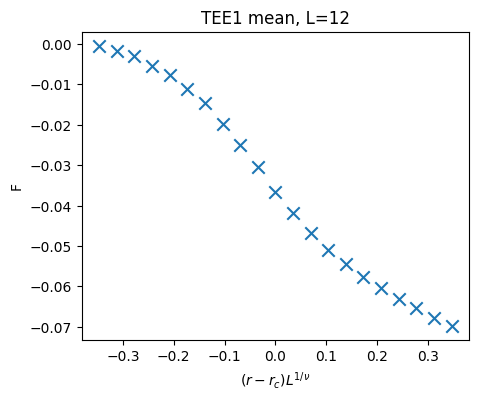

pc = 0.8000 ± nan
nu = 2.0000 ± nan
zeta = 2.0000 ± nan
=== TEE1 variance, L=12 ===


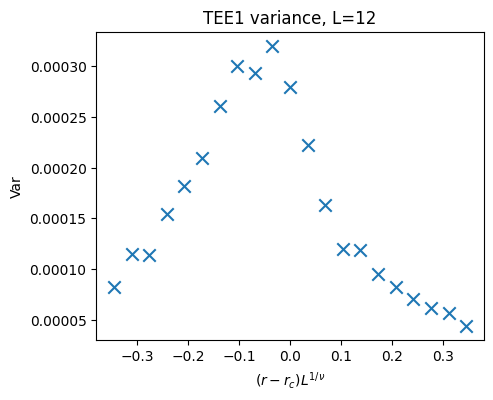

=== TEE2 mean, L=18 ===


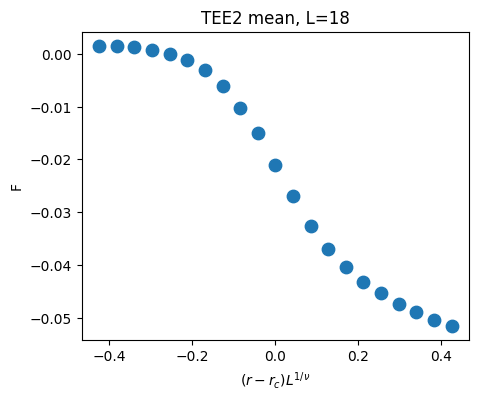

pc = 0.8000 ± nan
nu = 2.0000 ± nan
zeta = 2.0000 ± nan
=== TEE2 variance, L=18 ===


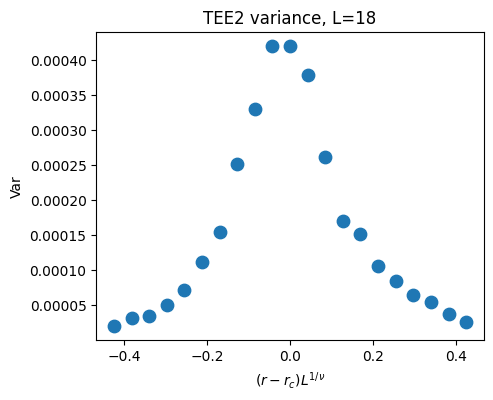

=== TEE3 mean, L=24 ===


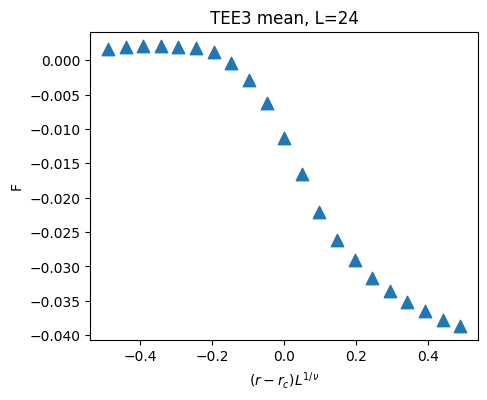

pc = 0.8000 ± nan
nu = 2.0000 ± nan
zeta = 2.0000 ± nan
=== TEE3 variance, L=24 ===


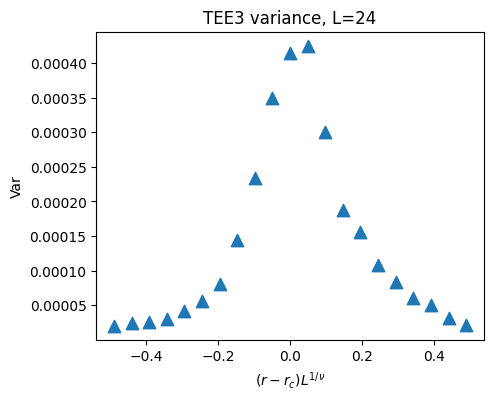

=== TEE4 mean, L=30 ===


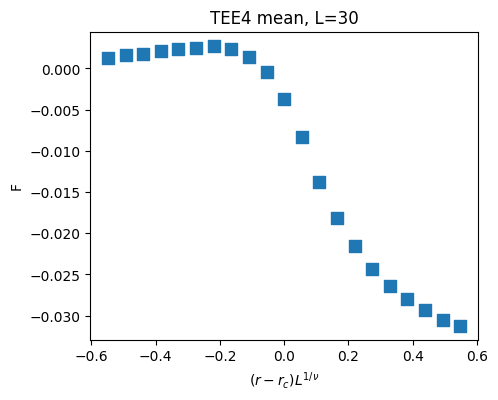

pc = 0.8000 ± nan
nu = 2.0000 ± nan
zeta = 2.0000 ± nan
=== TEE4 variance, L=30 ===


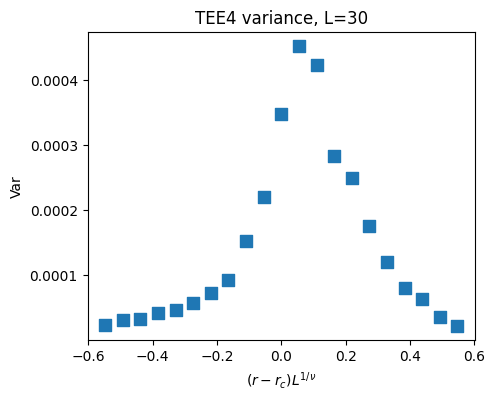

In [14]:
import numpy as np
import fssa
import matplotlib.pyplot as plt
import matplotlib.cm as cm

gamma = 0.5
markers = ['x', 'o', '^', 's']
cmap = cm.get_cmap('gnuplot')

# LをTEEごとに指定
L_list = [12, 18, 24, 30]  # TEE1,2,3,4
num_L = 1  # 各TEEは1つのL

# npzデータ
data = np.load("Lx_24_Nd_500_NT_17280_px_0.0_MPI_hexagonal1234.npz")
p_use = data['pg']

for tee_idx, L_use in enumerate(L_list, start=1):
    # 平均値
    a_mean  = np.array(data[f'TEE{tee_idx}_ave'], dtype=float).reshape(1,-1)
    da_mean = np.array(data[f'TEE{tee_idx}_err'], dtype=float).reshape(1,-1) * gamma

    # 分散
    a_var  = np.array(data[f'TEE{tee_idx}_var'], dtype=float).reshape(1,-1)
    da_var = np.array(data[f'TEE{tee_idx}_err'], dtype=float).reshape(1,-1) * gamma

    # 平均値 FSS
    print(f"=== TEE{tee_idx} mean, L={L_use} ===")
    ret = fssa.autoscale([L_use], p_use, a_mean, da_mean,
                          rho_c0=0.8, nu0=2, zeta0=2)
    xs, ys, dys = fssa.scaledata([L_use], p_use, a_mean, da_mean, ret.rho, ret.nu, ret.zeta)

    plt.figure(figsize=(5,4))
    plt.scatter(xs.T[:,0], ys.T[:,0], marker=markers[tee_idx-1], s=80)
    plt.xlabel(r'$(r-r_c)L^{1/\nu}$')
    plt.ylabel('F')
    plt.title(f'TEE{tee_idx} mean, L={L_use}')
    plt.show()

    print(f"pc = {ret.rho:.4f} ± {ret.drho:.4f}")
    print(f"nu = {ret.nu:.4f} ± {ret.dnu:.4f}")
    print(f"zeta = {ret.zeta:.4f} ± {ret.dzeta:.4f}")

    # 分散 FSS
    print(f"=== TEE{tee_idx} variance, L={L_use} ===")
    ret = fssa.autoscale([L_use], p_use, a_var, da_var,
                          rho_c0=0.8, nu0=2, zeta0=2)
    xs, ys, dys = fssa.scaledata([L_use], p_use, a_var, da_var, ret.rho, ret.nu, ret.zeta)

    plt.figure(figsize=(5,4))
    plt.scatter(xs.T[:,0], ys.T[:,0], marker=markers[tee_idx-1], s=80)
    plt.xlabel(r'$(r-r_c)L^{1/\nu}$')
    plt.ylabel('Var')
    plt.title(f'TEE{tee_idx} variance, L={L_use}')
    plt.show()


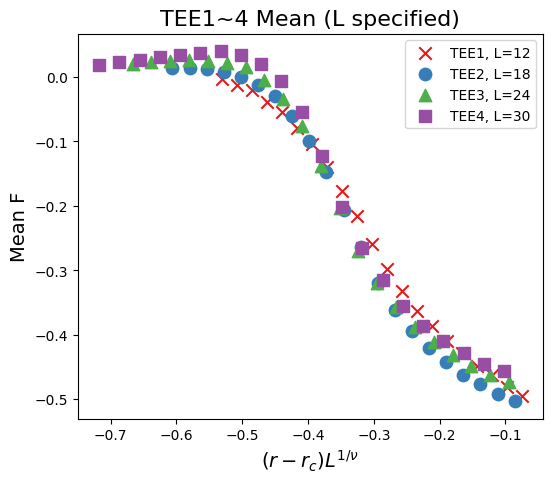

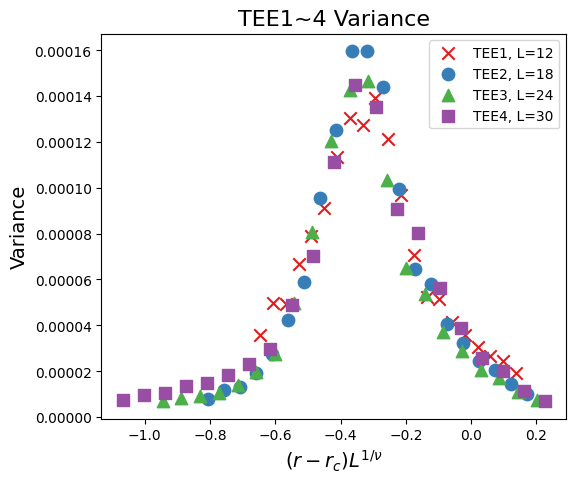

=== 平均 FSS ===
pc = 0.9330324764720757 ± nan
nu = 3.0242828369101638 ± nan
zeta = 0.6393085377263765 ± nan
S = 1199.3133290190847

=== 分散 FSS ===
pc = 0.864929995462808 ± 0.028565609007804114
nu = 1.8210583913889318 ± 0.4657670714501436
zeta = 2.431579125052213 ± 0.6104397672260281
S = 0.1169689689180052


In [14]:
import numpy as np
import fssa
import matplotlib.pyplot as plt
import matplotlib.cm as cm

gamma = 0.5
markers = ['x', 'o', '^', 's']
colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3']  

# TEEと対応するL
L_list = [12, 18, 24, 30]
TEE_keys = ['TEE1', 'TEE2', 'TEE3', 'TEE4']

# データ読み込み
data = np.load("Lx_24_Nd_500_NT_17280_px_0.0_MPI_hexagonal1234.npz")
p_use = data['pg']

# ----------------------
# 平均 FSS
# ----------------------
a_mean = np.array([data[f'{k}_ave'] for k in TEE_keys], dtype=float)
da_mean = np.array([data[f'{k}_err'] for k in TEE_keys], dtype=float) * gamma

ret_mean = fssa.autoscale(L_list, p_use, a_mean, da_mean, rho_c0=0.8, nu0=2, zeta0=2)
xs_mean, ys_mean, dys_mean = fssa.scaledata(L_list, p_use, a_mean, da_mean,
                                            ret_mean.rho, ret_mean.nu, ret_mean.zeta)

# ----------------------
# 分散 FSS （誤差は ave の err を流用）
# ----------------------
a_var = np.array([data[f'{k}_var'] for k in TEE_keys], dtype=float)
da_var = np.array([data[f'{k}_err'] for k in TEE_keys], dtype=float) * gamma  # 暫定流用

ret_var = fssa.autoscale(L_list, p_use, a_var, da_var, rho_c0=0.8, nu0=2, zeta0=2)
xs_var, ys_var, dys_var = fssa.scaledata(L_list, p_use, a_var, da_var,
                                         ret_var.rho, ret_var.nu, ret_var.zeta)

# ----------------------
# 平均のプロット
# ----------------------
fig, ax = plt.subplots(figsize=(6,5))
for i, L in enumerate(L_list):
    ax.scatter(xs_mean.T[:,i], ys_mean.T[:,i],
               marker=markers[i], color=colors[i],
               label=f'TEE{i+1}, L={L}', s=80)
ax.set_xlabel(r'$(r-r_c)L^{1/\nu}$', fontsize=14)
ax.set_ylabel('Mean F', fontsize=14)
ax.legend()
plt.title('TEE1~4 Mean (L specified)', fontsize=16)
plt.savefig("TEE_mean.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)

# ----------------------
# 分散のプロット
# ----------------------
fig, ax = plt.subplots(figsize=(6,5))
for i, L in enumerate(L_list):
    ax.scatter(xs_var.T[:,i], ys_var.T[:,i],
               marker=markers[i], color=colors[i],
               label=f'TEE{i+1}, L={L}', s=80)
ax.set_xlabel(r'$(r-r_c)L^{1/\nu}$', fontsize=14)
ax.set_ylabel('Variance', fontsize=14)
ax.legend()
plt.title('TEE1~4 Variance', fontsize=16)
plt.savefig("TEE_variance.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)

# ----------------------
# FSS 結果出力
# ----------------------
print("=== 平均 FSS ===")
print("pc =", ret_mean.rho, "±", ret_mean.drho)
print("nu =", ret_mean.nu, "±", ret_mean.dnu)
print("zeta =", ret_mean.zeta, "±", ret_mean.dzeta)
print("S =", fssa.quality(xs_mean, ys_mean, dys_mean))

print("\n=== 分散 FSS ===")
print("pc =", ret_var.rho, "±", ret_var.drho)
print("nu =", ret_var.nu, "±", ret_var.dnu)
print("zeta =", ret_var.zeta, "±", ret_var.dzeta)
print("S =", fssa.quality(xs_var, ys_var, dys_var))


In [27]:
import numpy as np
import fssa
import matplotlib.pyplot as plt
import matplotlib.cm as cm

gamma = 0.5
markers = ['x', 'o', '^', 's']
colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3']  

# TEEと対応するL
L_list = [18, 24, 30]
TEE_keys = ['TEE1', 'TEE2', 'TEE3', 'TEE4']

# データ読み込み
data = np.load("Lx_24_Nd_500_NT_17280_px_0.0_MPI_hexagonal1234.npz")
p_use = data['pg']

# ----------------------
# 平均 FSS
# ----------------------
a_mean = np.array([data[f'{k}_ave'] for k in TEE_keys], dtype=float)
da_mean = np.array([data[f'{k}_err'] for k in TEE_keys], dtype=float) * gamma

ret_mean = fssa.autoscale(L_list, p_use, a_mean, da_mean, rho_c0=0.8, nu0=2, zeta0=2)
xs_mean, ys_mean, dys_mean = fssa.scaledata(L_list, p_use, a_mean, da_mean,
                                            ret_mean.rho, ret_mean.nu, ret_mean.zeta)

# ----------------------
# 分散 FSS （誤差は ave の err を流用）
# ----------------------
a_var = np.array([data[f'{k}_var'] for k in TEE_keys], dtype=float)
da_var = np.array([data[f'{k}_err'] for k in TEE_keys], dtype=float) * gamma  # 暫定流用

ret_var = fssa.autoscale(L_list, p_use, a_var, da_var, rho_c0=0.8, nu0=2, zeta0=2)
xs_var, ys_var, dys_var = fssa.scaledata(L_list, p_use, a_var, da_var,
                                         ret_var.rho, ret_var.nu, ret_var.zeta)

# ----------------------
# 平均のプロット
# ----------------------
fig, ax = plt.subplots(figsize=(6,5))
for i, L in enumerate(L_list):
    ax.scatter(xs_mean.T[:,i], ys_mean.T[:,i],
               marker=markers[i], color=colors[i],
               label=f'TEE{i+1}, L={L}', s=80)
ax.set_xlabel(r'$(r-r_c)L^{1/\nu}$', fontsize=14)
ax.set_ylabel('Mean F', fontsize=14)
ax.legend()
plt.title('TEE1~4 Mean (L specified)', fontsize=16)
plt.savefig("TEE_mean.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)

# ----------------------
# 分散のプロット
# ----------------------
fig, ax = plt.subplots(figsize=(6,5))
for i, L in enumerate(L_list):
    ax.scatter(xs_var.T[:,i], ys_var.T[:,i],
               marker=markers[i], color=colors[i],
               label=f'TEE{i+1}, L={L}', s=80)
ax.set_xlabel(r'$(r-r_c)L^{1/\nu}$', fontsize=14)
ax.set_ylabel('Variance', fontsize=14)
ax.legend()
plt.title('TEE1~4 Variance', fontsize=16)
plt.savefig("TEE_variance.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)

# ----------------------
# FSS 結果出力
# ----------------------
print("=== 平均 FSS ===")
print("pc =", ret_mean.rho, "±", ret_mean.drho)
print("nu =", ret_mean.nu, "±", ret_mean.dnu)
print("zeta =", ret_mean.zeta, "±", ret_mean.dzeta)
print("S =", fssa.quality(xs_mean, ys_mean, dys_mean))

print("\n=== 分散 FSS ===")
print("pc =", ret_var.rho, "±", ret_var.drho)
print("nu =", ret_var.nu, "±", ret_var.dnu)
print("zeta =", ret_var.zeta, "±", ret_var.dzeta)
print("S =", fssa.quality(xs_var, ys_var, dys_var))


ValueError: a should have shape (l.size, rho.size)

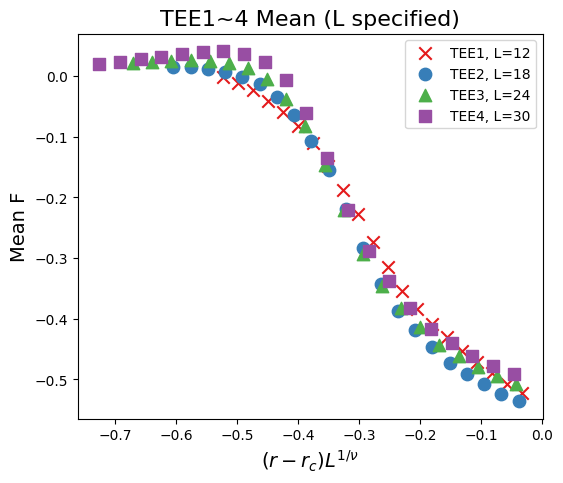

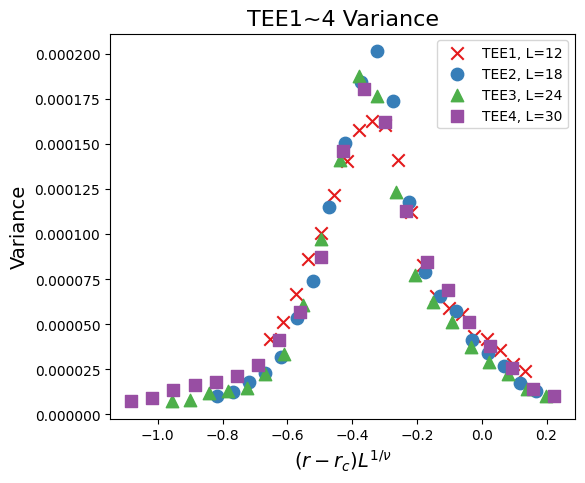

=== 平均 FSS ===
pc = 0.9136781417558111 ± 0.008503355355629677
nu = 2.779909285522029 ± 0.23186782862138694
zeta = 0.5277260952811538 ± 0.2673453863438834
S = 932.0812945343457

=== 分散 FSS ===
pc = 0.8658706865758572 ± 0.016774560613489933
nu = 1.8136784464527294 ± nan
zeta = 2.422311580631736 ± 0.33756374802032435
S = 0.13407554891218854


In [2]:
import numpy as np
import fssa
import matplotlib.pyplot as plt
import matplotlib.cm as cm

gamma = 0.5
markers = ['x', 'o', '^', 's']
colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3']  

# TEEと対応するL
L_list = [12, 18, 24, 30]
TEE_keys = ['TEE1', 'TEE2', 'TEE3', 'TEE4']

# データ読み込み
data = np.load("Lx_22_Nd_500_NT_14520_px_0.0_MPI_hexagonal1234.npz")
p_use = data['pg']

# ----------------------
# 平均 FSS
# ----------------------
a_mean = np.array([data[f'{k}_ave'] for k in TEE_keys], dtype=float)
da_mean = np.array([data[f'{k}_err'] for k in TEE_keys], dtype=float) * gamma

ret_mean = fssa.autoscale(L_list, p_use, a_mean, da_mean, rho_c0=0.8, nu0=2, zeta0=2)
xs_mean, ys_mean, dys_mean = fssa.scaledata(L_list, p_use, a_mean, da_mean,
                                            ret_mean.rho, ret_mean.nu, ret_mean.zeta)

# ----------------------
# 分散 FSS （誤差は ave の err を流用）
# ----------------------
a_var = np.array([data[f'{k}_var'] for k in TEE_keys], dtype=float)
da_var = np.array([data[f'{k}_err'] for k in TEE_keys], dtype=float) * gamma  # 暫定流用

ret_var = fssa.autoscale(L_list, p_use, a_var, da_var, rho_c0=0.8, nu0=2, zeta0=2)
xs_var, ys_var, dys_var = fssa.scaledata(L_list, p_use, a_var, da_var,
                                         ret_var.rho, ret_var.nu, ret_var.zeta)

# ----------------------
# 平均のプロット
# ----------------------
fig, ax = plt.subplots(figsize=(6,5))
for i, L in enumerate(L_list):
    ax.scatter(xs_mean.T[:,i], ys_mean.T[:,i],
               marker=markers[i], color=colors[i],
               label=f'TEE{i+1}, L={L}', s=80)
ax.set_xlabel(r'$(r-r_c)L^{1/\nu}$', fontsize=14)
ax.set_ylabel('Mean F', fontsize=14)
ax.legend()
plt.title('TEE1~4 Mean (L specified)', fontsize=16)
plt.savefig("TEE_mean.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)

# ----------------------
# 分散のプロット
# ----------------------
fig, ax = plt.subplots(figsize=(6,5))
for i, L in enumerate(L_list):
    ax.scatter(xs_var.T[:,i], ys_var.T[:,i],
               marker=markers[i], color=colors[i],
               label=f'TEE{i+1}, L={L}', s=80)
ax.set_xlabel(r'$(r-r_c)L^{1/\nu}$', fontsize=14)
ax.set_ylabel('Variance', fontsize=14)
ax.legend()
plt.title('TEE1~4 Variance', fontsize=16)
plt.savefig("TEE_variance.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)

# ----------------------
# FSS 結果出力
# ----------------------
print("=== 平均 FSS ===")
print("pc =", ret_mean.rho, "±", ret_mean.drho)
print("nu =", ret_mean.nu, "±", ret_mean.dnu)
print("zeta =", ret_mean.zeta, "±", ret_mean.dzeta)
print("S =", fssa.quality(xs_mean, ys_mean, dys_mean))

print("\n=== 分散 FSS ===")
print("pc =", ret_var.rho, "±", ret_var.drho)
print("nu =", ret_var.nu, "±", ret_var.dnu)
print("zeta =", ret_var.zeta, "±", ret_var.dzeta)
print("S =", fssa.quality(xs_var, ys_var, dys_var))


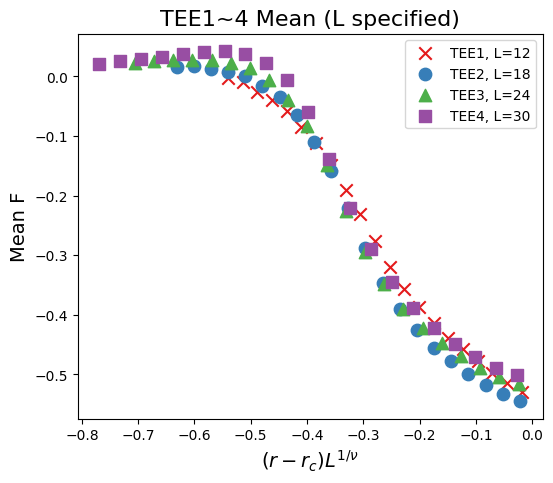

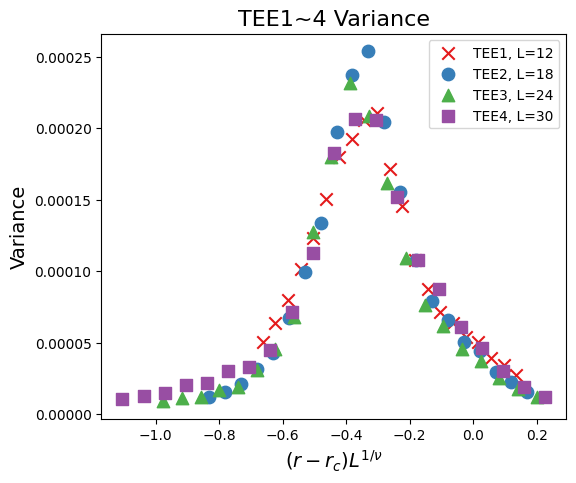

=== 平均 FSS ===
pc = 0.9071631867855829 ± 0.006056279750445226
nu = 2.591947270086914 ± 0.29846736896257803
zeta = 0.47752655831870006 ± 0.2507502186321743
S = 1547.8102005052992

=== 分散 FSS ===
pc = 0.8659994633749868 ± 0.025706348368140525
nu = 1.7942899926062688 ± 0.599938336155639
zeta = 2.37508150118033 ± 0.7150109348226135
S = 0.2884011404389501


In [3]:
import numpy as np
import fssa
import matplotlib.pyplot as plt
import matplotlib.cm as cm

gamma = 0.5
markers = ['x', 'o', '^', 's']
colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3']  

# TEEと対応するL
L_list = [12, 18, 24, 30]
TEE_keys = ['TEE1', 'TEE2', 'TEE3', 'TEE4']

# データ読み込み
data = np.load("Lx_20_Nd_1000_NT_12000_px_0.0_MPI_hexagonal1234.npz")
p_use = data['pg']

# ----------------------
# 平均 FSS
# ----------------------
a_mean = np.array([data[f'{k}_ave'] for k in TEE_keys], dtype=float)
da_mean = np.array([data[f'{k}_err'] for k in TEE_keys], dtype=float) * gamma

ret_mean = fssa.autoscale(L_list, p_use, a_mean, da_mean, rho_c0=0.8, nu0=2, zeta0=2)
xs_mean, ys_mean, dys_mean = fssa.scaledata(L_list, p_use, a_mean, da_mean,
                                            ret_mean.rho, ret_mean.nu, ret_mean.zeta)

# ----------------------
# 分散 FSS （誤差は ave の err を流用）
# ----------------------
a_var = np.array([data[f'{k}_var'] for k in TEE_keys], dtype=float)
da_var = np.array([data[f'{k}_err'] for k in TEE_keys], dtype=float) * gamma  # 暫定流用

ret_var = fssa.autoscale(L_list, p_use, a_var, da_var, rho_c0=0.8, nu0=2, zeta0=2)
xs_var, ys_var, dys_var = fssa.scaledata(L_list, p_use, a_var, da_var,
                                         ret_var.rho, ret_var.nu, ret_var.zeta)

# ----------------------
# 平均のプロット
# ----------------------
fig, ax = plt.subplots(figsize=(6,5))
for i, L in enumerate(L_list):
    ax.scatter(xs_mean.T[:,i], ys_mean.T[:,i],
               marker=markers[i], color=colors[i],
               label=f'TEE{i+1}, L={L}', s=80)
ax.set_xlabel(r'$(r-r_c)L^{1/\nu}$', fontsize=14)
ax.set_ylabel('Mean F', fontsize=14)
ax.legend()
plt.title('TEE1~4 Mean (L specified)', fontsize=16)
plt.savefig("TEE_mean.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)

# ----------------------
# 分散のプロット
# ----------------------
fig, ax = plt.subplots(figsize=(6,5))
for i, L in enumerate(L_list):
    ax.scatter(xs_var.T[:,i], ys_var.T[:,i],
               marker=markers[i], color=colors[i],
               label=f'TEE{i+1}, L={L}', s=80)
ax.set_xlabel(r'$(r-r_c)L^{1/\nu}$', fontsize=14)
ax.set_ylabel('Variance', fontsize=14)
ax.legend()
plt.title('TEE1~4 Variance', fontsize=16)
plt.savefig("TEE_variance.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)

# ----------------------
# FSS 結果出力
# ----------------------
print("=== 平均 FSS ===")
print("pc =", ret_mean.rho, "±", ret_mean.drho)
print("nu =", ret_mean.nu, "±", ret_mean.dnu)
print("zeta =", ret_mean.zeta, "±", ret_mean.dzeta)
print("S =", fssa.quality(xs_mean, ys_mean, dys_mean))

print("\n=== 分散 FSS ===")
print("pc =", ret_var.rho, "±", ret_var.drho)
print("nu =", ret_var.nu, "±", ret_var.dnu)
print("zeta =", ret_var.zeta, "±", ret_var.dzeta)
print("S =", fssa.quality(xs_var, ys_var, dys_var))


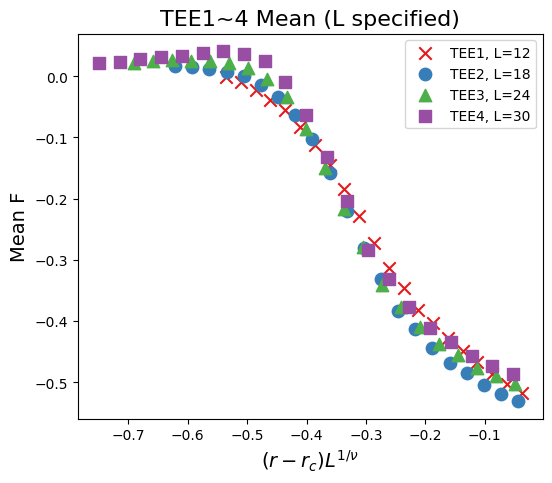

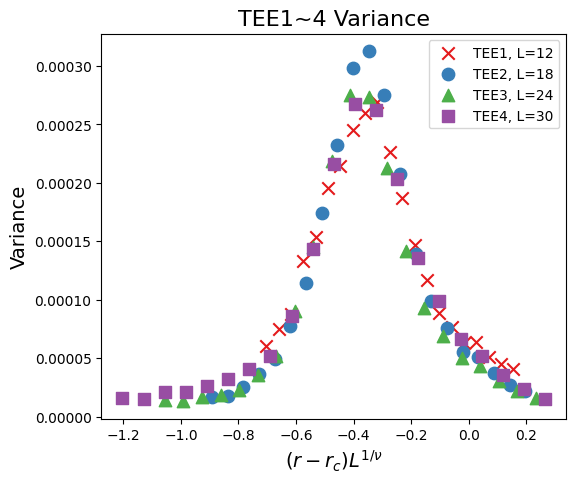

=== 平均 FSS ===
pc = 0.9150037575757983 ± nan
nu = 2.7234216890625413 ± 5.9186436137543055
zeta = 0.5259606237531501 ± 0.9399833581086071
S = 977.843630839883

=== 分散 FSS ===
pc = 0.8638126643984104 ± 0.008304982624472745
nu = 1.7057871007396264 ± nan
zeta = 2.3956733709098863 ± nan
S = 0.40325943739507364


In [31]:
import numpy as np
import fssa
import matplotlib.pyplot as plt
import matplotlib.cm as cm

gamma = 0.5
markers = ['x', 'o', '^', 's']
colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3']  

# TEEと対応するL
L_list = [12, 18, 24, 30]
TEE_keys = ['TEE1', 'TEE2', 'TEE3', 'TEE4']

#L_list = [18, 24, 30]
#TEE_keys = ['TEE2', 'TEE3', 'TEE4']

# データ読み込み
data = np.load("Lx_16_Nd_1000_NT_7680_px_0.0_MPI_hexagonal1234.npz")
p_use = data['pg']

# ----------------------
# 平均 FSS
# ----------------------
a_mean = np.array([data[f'{k}_ave'] for k in TEE_keys], dtype=float)
da_mean = np.array([data[f'{k}_err'] for k in TEE_keys], dtype=float) * gamma

ret_mean = fssa.autoscale(L_list, p_use, a_mean, da_mean, rho_c0=0.8, nu0=2, zeta0=2)
xs_mean, ys_mean, dys_mean = fssa.scaledata(L_list, p_use, a_mean, da_mean,
                                            ret_mean.rho, ret_mean.nu, ret_mean.zeta)

# ----------------------
# 分散 FSS （誤差は ave の err を流用）
# ----------------------
a_var = np.array([data[f'{k}_var'] for k in TEE_keys], dtype=float)
da_var = np.array([data[f'{k}_err'] for k in TEE_keys], dtype=float) * gamma  # 暫定流用

ret_var = fssa.autoscale(L_list, p_use, a_var, da_var, rho_c0=0.8, nu0=2, zeta0=2)
xs_var, ys_var, dys_var = fssa.scaledata(L_list, p_use, a_var, da_var,
                                         ret_var.rho, ret_var.nu, ret_var.zeta)

# ----------------------
# 平均のプロット
# ----------------------
fig, ax = plt.subplots(figsize=(6,5))
for i, L in enumerate(L_list):
    ax.scatter(xs_mean.T[:,i], ys_mean.T[:,i],
               marker=markers[i], color=colors[i],
               label=f'TEE{i+1}, L={L}', s=80)
ax.set_xlabel(r'$(r-r_c)L^{1/\nu}$', fontsize=14)
ax.set_ylabel('Mean F', fontsize=14)
ax.legend()
plt.title('TEE1~4 Mean (L specified)', fontsize=16)
plt.savefig("TEE_mean.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)

# ----------------------
# 分散のプロット
# ----------------------
fig, ax = plt.subplots(figsize=(6,5))
for i, L in enumerate(L_list):
    ax.scatter(xs_var.T[:,i], ys_var.T[:,i],
               marker=markers[i], color=colors[i],
               label=f'TEE{i+1}, L={L}', s=80)
ax.set_xlabel(r'$(r-r_c)L^{1/\nu}$', fontsize=14)
ax.set_ylabel('Variance', fontsize=14)
ax.legend()
plt.title('TEE1~4 Variance', fontsize=16)
plt.savefig("TEE_variance.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)

# ----------------------
# FSS 結果出力
# ----------------------
print("=== 平均 FSS ===")
print("pc =", ret_mean.rho, "±", ret_mean.drho)
print("nu =", ret_mean.nu, "±", ret_mean.dnu)
print("zeta =", ret_mean.zeta, "±", ret_mean.dzeta)
print("S =", fssa.quality(xs_mean, ys_mean, dys_mean))

print("\n=== 分散 FSS ===")
print("pc =", ret_var.rho, "±", ret_var.drho)
print("nu =", ret_var.nu, "±", ret_var.dnu)
print("zeta =", ret_var.zeta, "±", ret_var.dzeta)
print("S =", fssa.quality(xs_var, ys_var, dys_var))
